Business Understanding

#Business Understanding
Syria Tel is facing a challege with customer churn as customers are leavung the service. Losing customers is costly due to the lost revenue and the expenses that are associated with acquiring new customers. Prediciting which customers are likely to churn allows Syria Tel to take proactive measures such as offering personalized promotions, improving customer service and adjusting pricing strategies to retain them. 

#Problem Statement
Customer churn is a major issue in the industry as it leads to revenue loss and increased customer acquisition costs. The challenge is to develop a machine learning model that can perfectly predict whether a customer will churn based in historical usage and demographic data. Identifying patterns and risk factors associated with the moving customers will assist the company implement the targeted retention strategies.

Given customer attributes such as call usage, account information, contract type, and service engagement metrics, we aim to:

Classification Task: Predict whether a customer will leave SyriaTel or remain a subscriber.
Pattern Analysis: Identify key factors influencing customer churn to support business decision-making.

#Objectives
Classification
Develop a predictive model to classify customers as either churners or non-churners.
Engineer relevant features from customer usage patterns and demographics.
Optimize model performance using feature selection, hyperparameter tuning and evaluation metrics. 
Business Insights & Retention Strategy
Identify the key drivers of churn.
Provide actionable recommendations for customer retention strategies based on predictive insights.
Help SyriaTel reduce churn rates and improve customer loyalty through targeted marketing and service improvements.

Data Understanding

In [76]:
#import libraries
import pandas as pd
import numpy as np

# data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# feature selection and importance
from sklearn.feature_selection import SelectKBest, chi2

# Modelling and algorithms for supervised learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from sklearn.tree import plot_tree
from sklearn.metrics import roc_curve, auc, roc_auc_score
from sklearn.feature_selection import RFE

# filter warnings
import warnings
warnings.filterwarnings('ignore')

In [41]:
df= pd.read_csv('bigml.data.csv')
df.head()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,415,382-4657,no,yes,25,265.1,110,45.07,...,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,371-7191,no,yes,26,161.6,123,27.47,...,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,358-1921,no,no,0,243.4,114,41.38,...,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,375-9999,yes,no,0,299.4,71,50.90,...,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,330-6626,yes,no,0,166.7,113,28.34,...,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [42]:
df.tail()

,state,account length,area code,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,...,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
3328,AZ,192,415,414-4276,no,yes,36,156.2,77,26.55,...,126,18.32,279.1,83,12.56,9.9,6,2.67,2,False
3329,WV,68,415,370-3271,no,no,0,231.1,57,39.29,...,55,13.04,191.3,123,8.61,9.6,4,2.59,3,False
3330,RI,28,510,328-8230,no,no,0,180.8,109,30.74,...,58,24.55,191.9,91,8.64,14.1,6,3.81,2,False
3331,CT,184,510,364-6381,yes,no,0,213.8,105,36.35,...,84,13.57,139.2,137,6.26,5.0,10,1.35,2,False
3332,TN,74,415,400-4344,no,yes,25,234.4,113,39.85,...,82,22.60,241.4,77,10.86,13.7,4,3.70,0,False


In [43]:
# Overview of dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

In [44]:
df.shape

(3333, 21)

In [45]:
df.describe()

,account length,area code,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls
count,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000,3333.000000
mean,101.064806,437.182418,8.099010,179.775098,100.435644,30.562307,200.980348,100.114311,17.083540,200.872037,100.107711,9.039325,10.237294,4.479448,2.764581,1.562856
std,39.822106,42.371290,13.688365,54.467389,20.069084,9.259435,50.713844,19.922625,4.310668,50.573847,19.568609,2.275873,2.791840,2.461214,0.753773,1.315491
min,1.000000,408.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,23.200000,33.000000,1.040000,0.000000,0.000000,0.000000,0.000000
25%,74.000000,408.000000,0.000000,143.700000,87.000000,24.430000,166.600000,87.000000,14.160000,167.000000,87.000000,7.520000,8.500000,3.000000,2.300000,1.000000
50%,101.000000,415.000000,0.000000,179.400000,101.000000,30.500000,201.400000,100.000000,17.120000,201.200000,100.000000,9.050000,10.300000,4.000000,2.780000,1.000000
75%,127.000000,510.000000,20.000000,216.400000,114.000000,36.790000,235.300000,114.000000,20.000000,235.300000,113.000000,10.590000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,51.000000,350.800000,165.000000,59.640000,363.700000,170.000000,30.910000,395.000000,175.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3333 entries, 0 to 3332
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   3333 non-null   object 
 1   account length          3333 non-null   int64  
 2   area code               3333 non-null   int64  
 3   phone number            3333 non-null   object 
 4   international plan      3333 non-null   object 
 5   voice mail plan         3333 non-null   object 
 6   number vmail messages   3333 non-null   int64  
 7   total day minutes       3333 non-null   float64
 8   total day calls         3333 non-null   int64  
 9   total day charge        3333 non-null   float64
 10  total eve minutes       3333 non-null   float64
 11  total eve calls         3333 non-null   int64  
 12  total eve charge        3333 non-null   float64
 13  total night minutes     3333 non-null   float64
 14  total night calls       3333 non-null   

Data Cleaning 

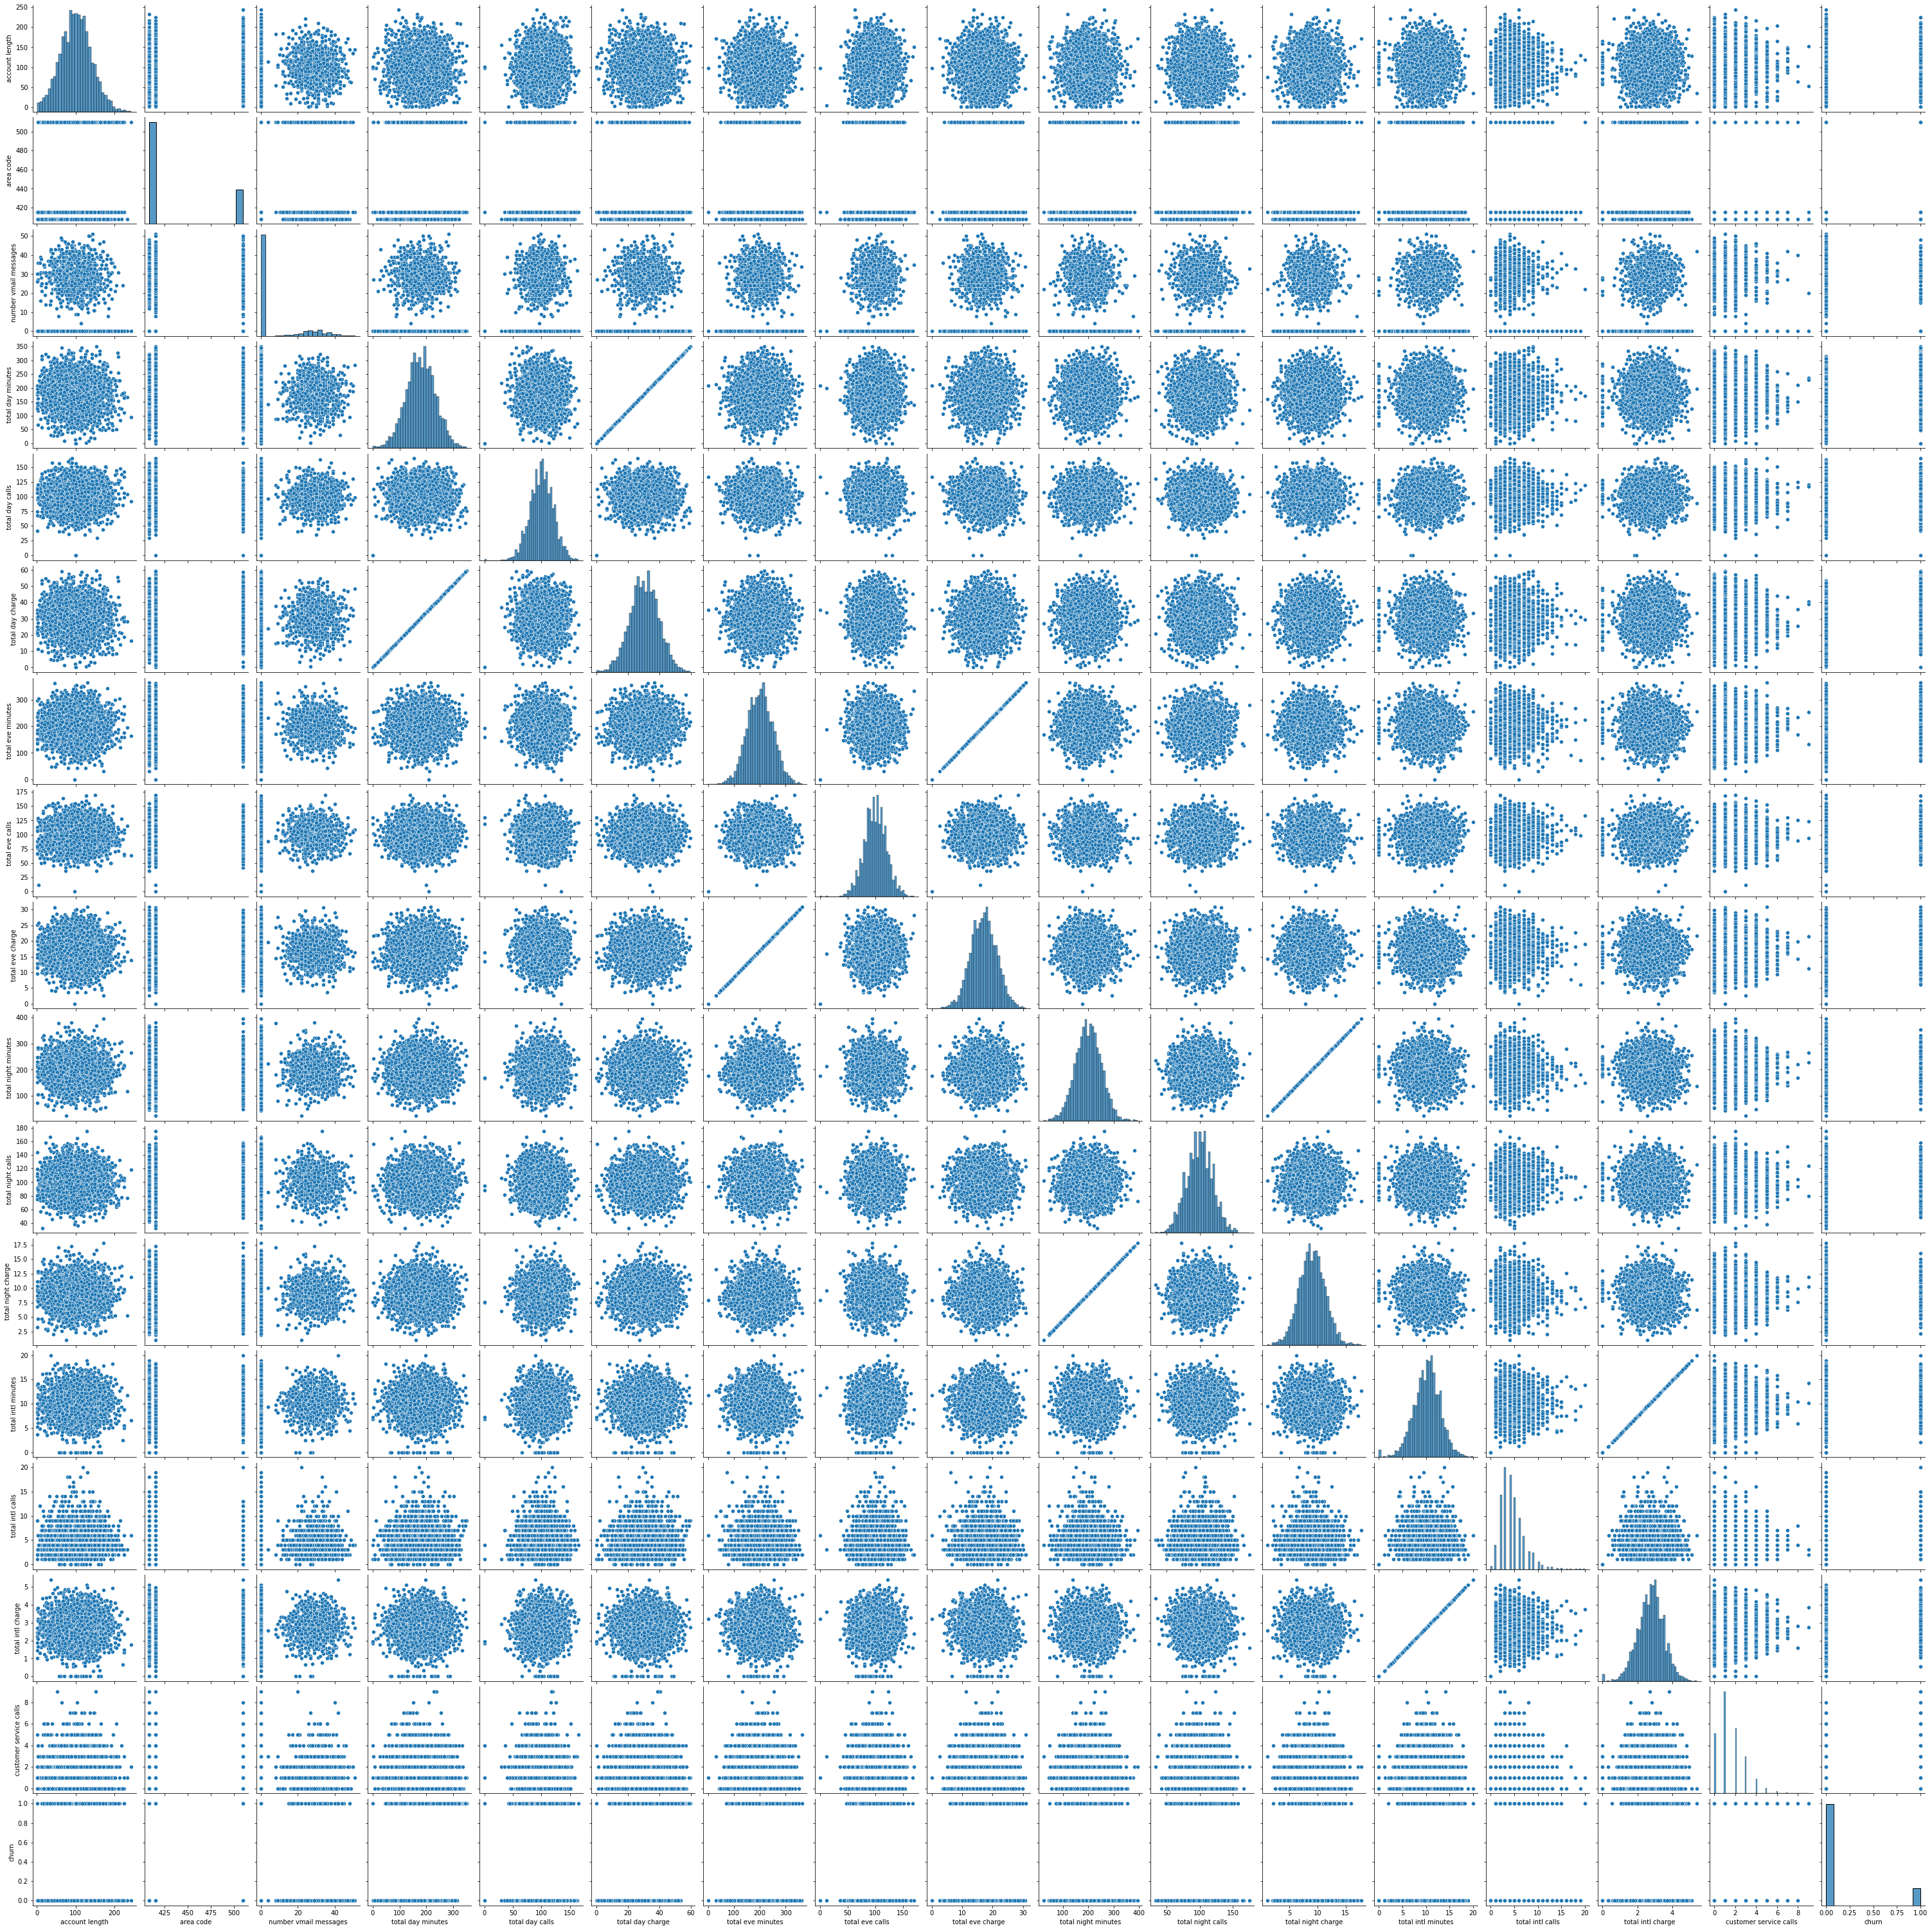

In [48]:
sns.pairplot(df)

In [49]:
# missing values summary per column
df.isna().mean()*100

state                     0.0
account length            0.0
area code                 0.0
phone number              0.0
international plan        0.0
voice mail plan           0.0
number vmail messages     0.0
total day minutes         0.0
total day calls           0.0
total day charge          0.0
total eve minutes         0.0
total eve calls           0.0
total eve charge          0.0
total night minutes       0.0
total night calls         0.0
total night charge        0.0
total intl minutes        0.0
total intl calls          0.0
total intl charge         0.0
customer service calls    0.0
churn                     0.0
dtype: float64

In [51]:
# duplicated values summary per column
df[df.duplicated()].count()

state                     0
account length            0
area code                 0
phone number              0
international plan        0
voice mail plan           0
number vmail messages     0
total day minutes         0
total day calls           0
total day charge          0
total eve minutes         0
total eve calls           0
total eve charge          0
total night minutes       0
total night calls         0
total night charge        0
total intl minutes        0
total intl calls          0
total intl charge         0
customer service calls    0
churn                     0
dtype: int64

In [37]:
print(df.isnull().values.any()) 

False


In [52]:
print(df.groupby("area code")["churn"].mean())


area code
408    0.145585
415    0.142598
510    0.148810
Name: churn, dtype: float64


In [131]:
print("\nStatistical Summary:\n", df.describe())



Statistical Summary:
        account length  phone number  international plan  voice mail plan  \
count    3.333000e+03  3.333000e+03        3.333000e+03     3.333000e+03   
mean    -8.527366e-18 -3.197762e-18       -1.385697e-17     6.182340e-17   
std      1.000150e+00  1.000150e+00        1.000150e+00     1.000150e+00   
min     -2.513172e+00 -1.731531e+00       -3.275805e-01    -6.183963e-01   
25%     -6.797448e-01 -8.657656e-01       -3.275805e-01    -6.183963e-01   
50%     -1.627644e-03  2.664802e-18       -3.275805e-01    -6.183963e-01   
75%      6.513740e-01  8.657656e-01       -3.275805e-01     1.617086e+00   
max      3.564766e+00  1.731531e+00        3.052685e+00     1.617086e+00   

       number vmail messages  total day minutes  total day calls  \
count           3.333000e+03       3.333000e+03     3.333000e+03   
mean           -5.969156e-17      -5.329603e-19     3.197762e-18   
std             1.000150e+00       1.000150e+00     1.000150e+00   
min            -5.91

In [53]:
#The area code does not strongly infuence churn thus it can be dropped. 
df.drop(columns=["area code"], inplace=True)

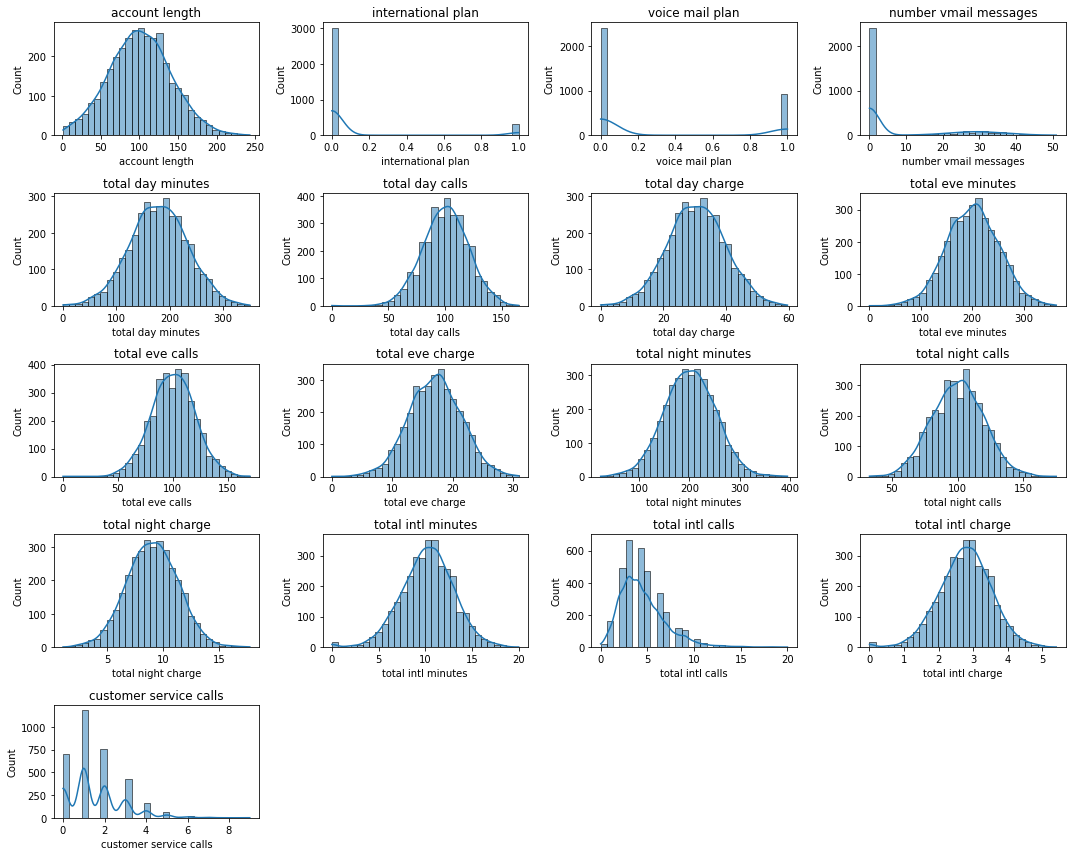

In [59]:
# Univariate analysis of numerical columns
# select Numerical columns
num_cols = len(numerical_cols)

# Dynamically calculate rows and columns
rows = math.ceil(num_cols / 4)  # Adjust rows based on number of columns
cols = min(num_cols, 4)  # Maximum of 4 columns

plt.figure(figsize=(15, 12))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, cols, i)
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()


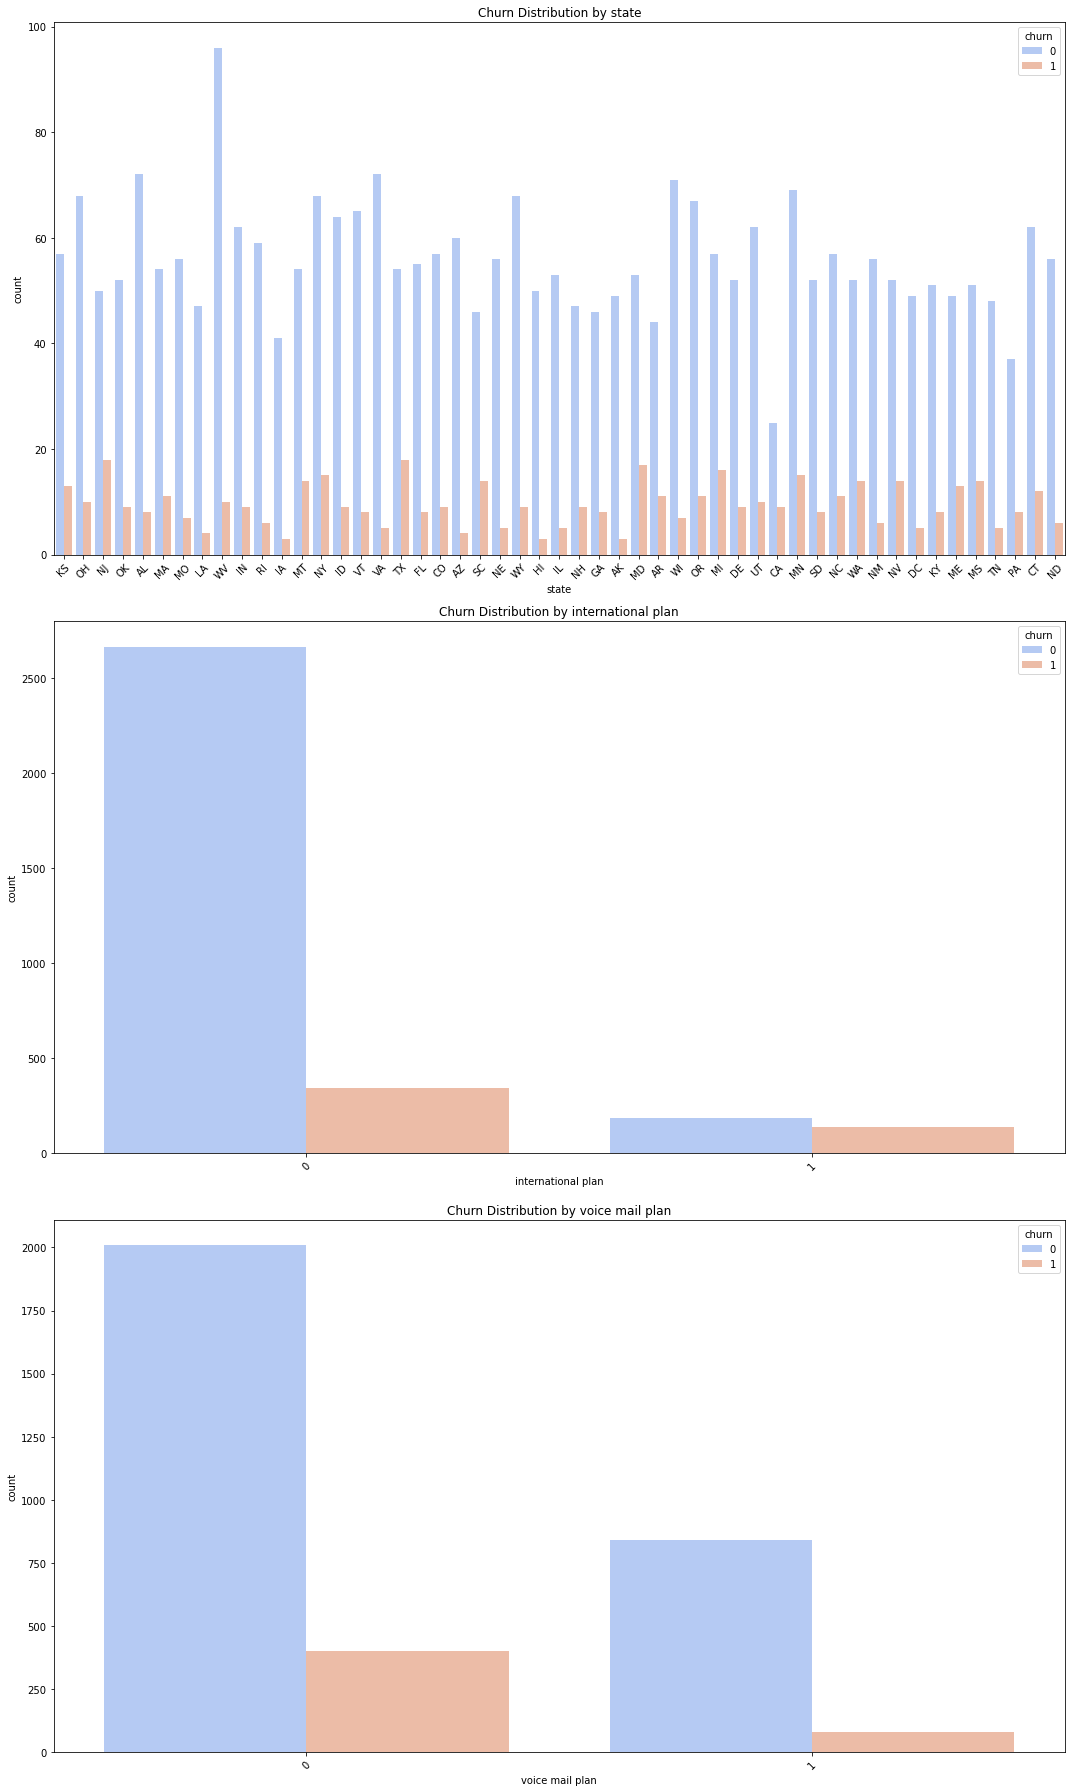

In [64]:
# define categorical columns
categorical_cols = ["state", "international plan", "voice mail plan"]

# figure size
plt.figure(figsize=(15, 25))
#
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 1, i)
    sns.countplot(x=df[col], hue=df["churn"], palette="coolwarm")
    plt.title(f"Churn Distribution by {col}")
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [54]:
#convert the categorical variables
df["international plan"] = df["international plan"].map({"yes": 1, "no": 0})
df["voice mail plan"] = df["voice mail plan"].map({"yes": 1, "no": 0})
df["churn"] = df["churn"].astype(int)  # Convert True/False to 1/0


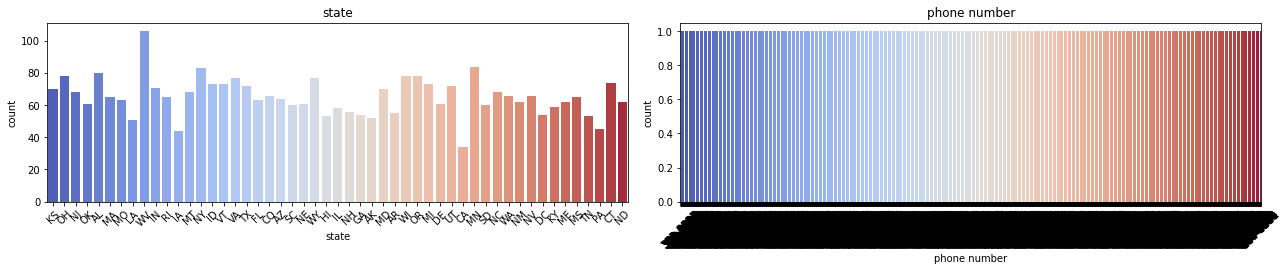

In [60]:
# Univariate analysis for categorical columns
# define and select categorical columns
categorical_cols = df.select_dtypes(include=['object', 'bool']).columns

plt.figure(figsize=(18, 10))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(3, 2, i)
    sns.countplot(x=df[col], palette="coolwarm")
    plt.title(col)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
#Check for duplicate rows
duplicate_rows = df[df.duplicated()]
print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")



Number of duplicate rows: 0


In [56]:
print(df.columns)

Index(['state', 'account length', 'phone number', 'international plan',
       'voice mail plan', 'number vmail messages', 'total day minutes',
       'total day calls', 'total day charge', 'total eve minutes',
       'total eve calls', 'total eve charge', 'total night minutes',
       'total night calls', 'total night charge', 'total intl minutes',
       'total intl calls', 'total intl charge', 'customer service calls',
       'churn'],
      dtype='object')


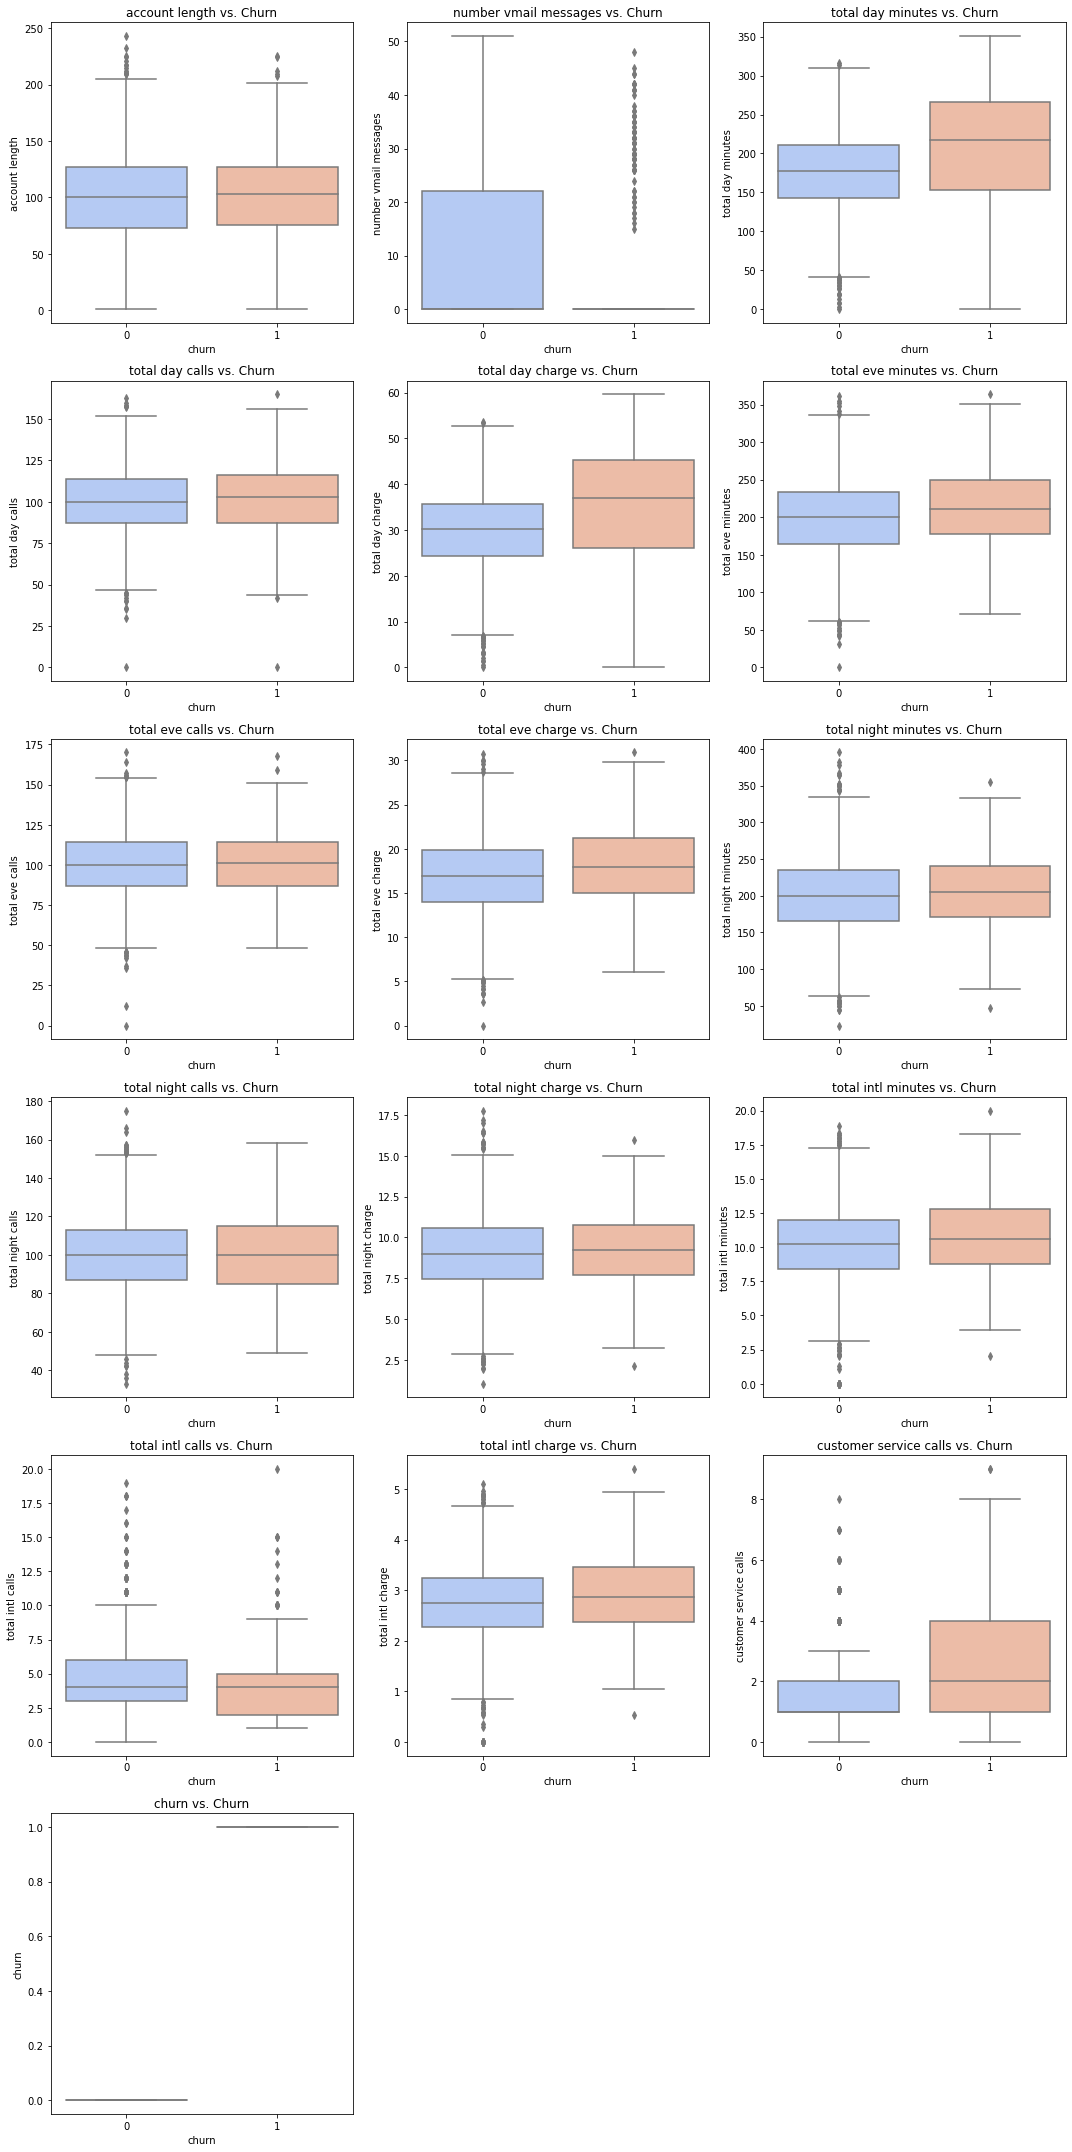

In [62]:
# Define numerical columns
numerical_cols = [
    "account length", "number vmail messages", "total day minutes",
    "total day calls", "total day charge", "total eve minutes", "total eve calls",
    "total eve charge", "total night minutes", "total night calls", "total night charge",
    "total intl minutes", "total intl calls", "total intl charge", "customer service calls", "churn"
]
# Adjust the grid size dynamically based on number of plots
rows = (len(numerical_cols) // 3) + 1  # Adjust rows automatically

plt.figure(figsize=(15, rows * 5))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(rows, 3, i)
    sns.boxplot(x=df["churn"], y=df[col], palette="coolwarm")
    plt.title(f"{col} vs. Churn")

plt.tight_layout()
plt.show()

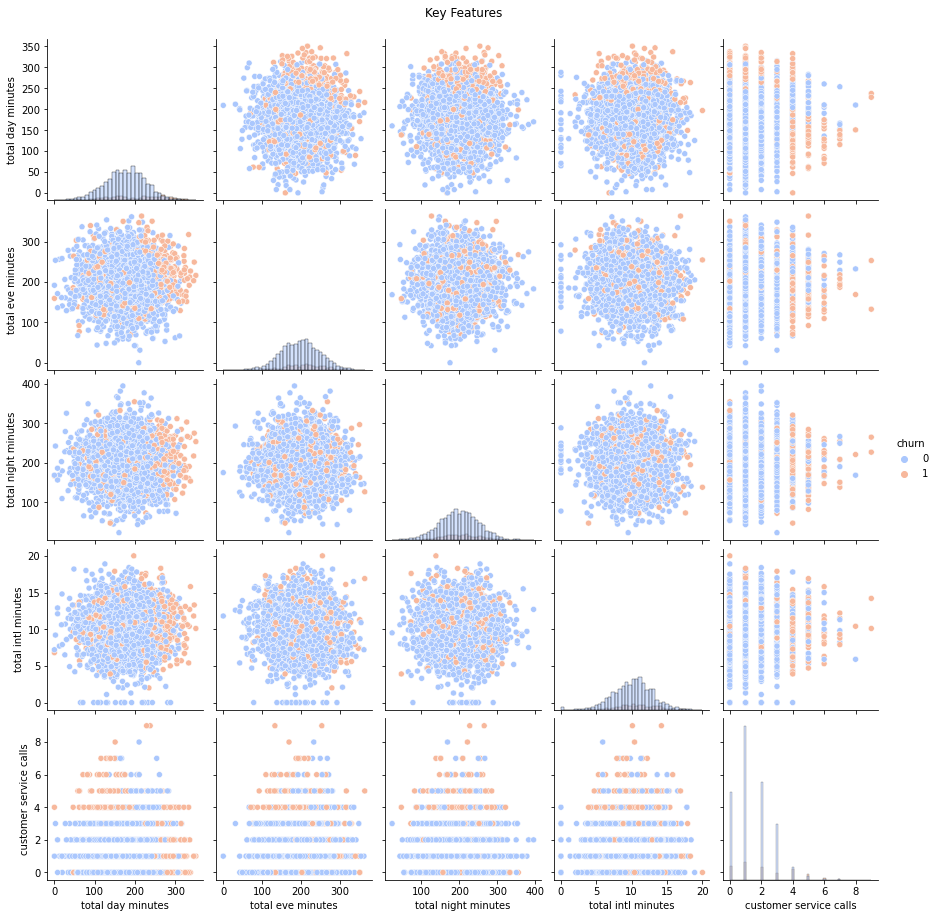

In [65]:
# Select relevant numerical columns
multivariate_cols = ["total day minutes", "total eve minutes", "total night minutes",
                     "total intl minutes", "customer service calls", "churn"]

# Pairplot to analyze relationships
sns.pairplot(df[multivariate_cols], hue="churn", palette="coolwarm", diag_kind="hist")
plt.suptitle("Key Features", y=1.02)
plt.show()

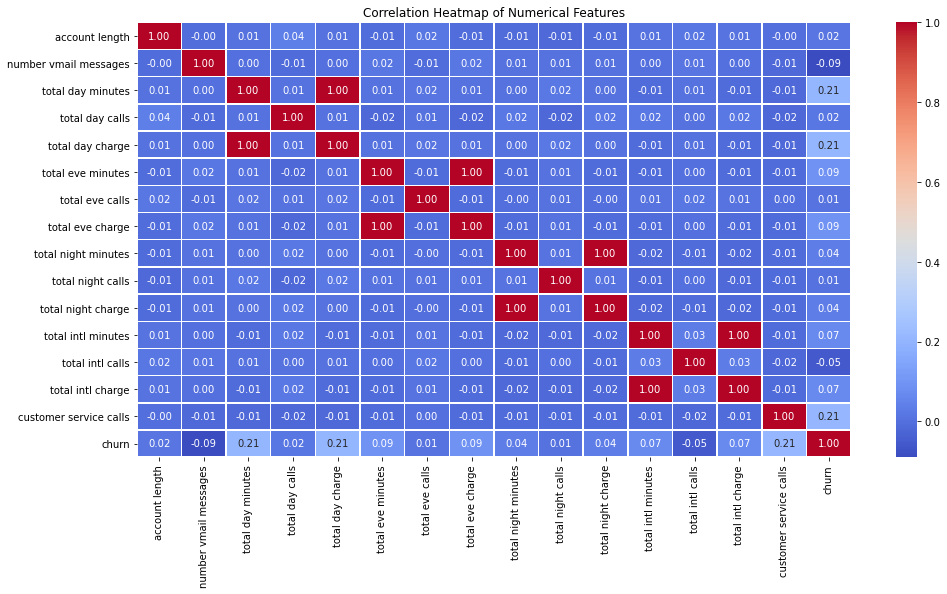

In [63]:
# figure size
plt.figure(figsize=(16, 8))

# correlation matrix
corr_matrix = df[numerical_cols].corr()

# visualize heatmap
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", linewidths=0.5, fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

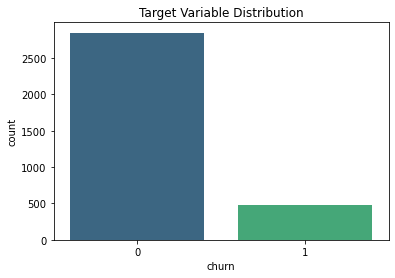

In [134]:
#Target Variable Distribution ---
target_var = "churn"
plt.figure(figsize=(6, 4))
sns.countplot(x=df[target_var], palette="viridis")
plt.title("Target Variable Distribution")
plt.show()

In [20]:
import numpy as np

# Define a function to detect and remove outliers using IQR
def remove_outliers_iqr(df, columns):
    df_filtered = df.copy()  # Ensure df_filtered is initialized properly
    for col in columns:
        Q1 = df_filtered[col].quantile(0.25)
        Q3 = df_filtered[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        # Filter only the numeric column but keep all categorical columns
        df_filtered = df_filtered[~((df_filtered[col] < lower_bound) | (df_filtered[col] > upper_bound))]
    
    return df_filtered

# Select only numeric columns (preserves categorical variables)
num_cols = df.select_dtypes(include=np.number).columns  

# Apply IQR method without removing categorical columns
df_cleaned = remove_outliers_iqr(df, num_cols)

# Verify 'state' is still present
print("Columns after outlier removal:", df_cleaned.columns.tolist())
print("Unique states remaining:", df_cleaned['state'].nunique())  # Check if all states are still there


Columns after outlier removal: ['state', 'account length', 'international plan', 'voice mail plan', 'number vmail messages', 'total day minutes', 'total day calls', 'total day charge', 'total eve minutes', 'total eve calls', 'total eve charge', 'total night minutes', 'total night calls', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls', 'churn']
Unique states remaining: 51


In [21]:
#Verify changes
import matplotlib.pyplot as plt
import seaborn as sns
print(df_cleaned.describe())

       account length  international plan  voice mail plan  \
count     2328.000000              2328.0      2328.000000   
mean       100.178694                 0.0         0.292096   
std         39.222907                 0.0         0.454824   
min          1.000000                 0.0         0.000000   
25%         73.000000                 0.0         0.000000   
50%        100.000000                 0.0         0.000000   
75%        127.000000                 0.0         1.000000   
max        205.000000                 0.0         1.000000   

       number vmail messages  total day minutes  total day calls  \
count            2328.000000        2328.000000      2328.000000   
mean                8.506443         173.986684       100.298969   
std                13.858359          48.633070        19.030768   
min                 0.000000          37.700000        49.000000   
25%                 0.000000         141.700000        87.000000   
50%                 0.000000     

In [117]:
numeric_cols = df.select_dtypes(include=np.number).columns
skewness = df[numeric_cols].skew()

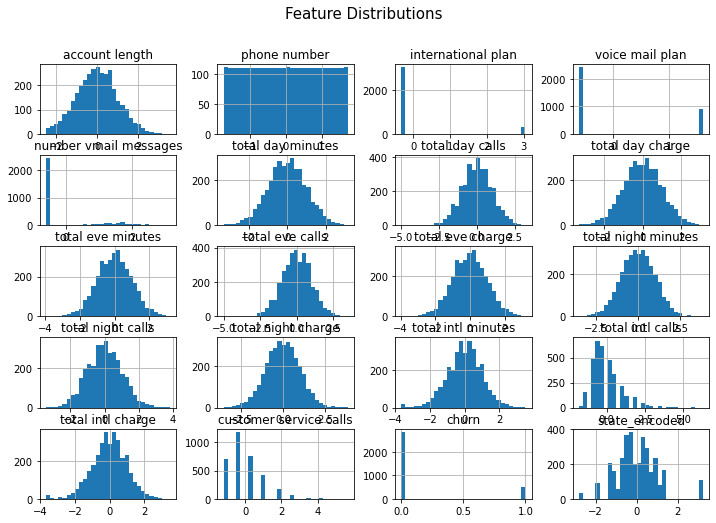

In [135]:
# Histograms
df[numeric_cols].hist(figsize=(12, 8), bins=30)
plt.suptitle("Feature Distributions", fontsize=15)
plt.show()

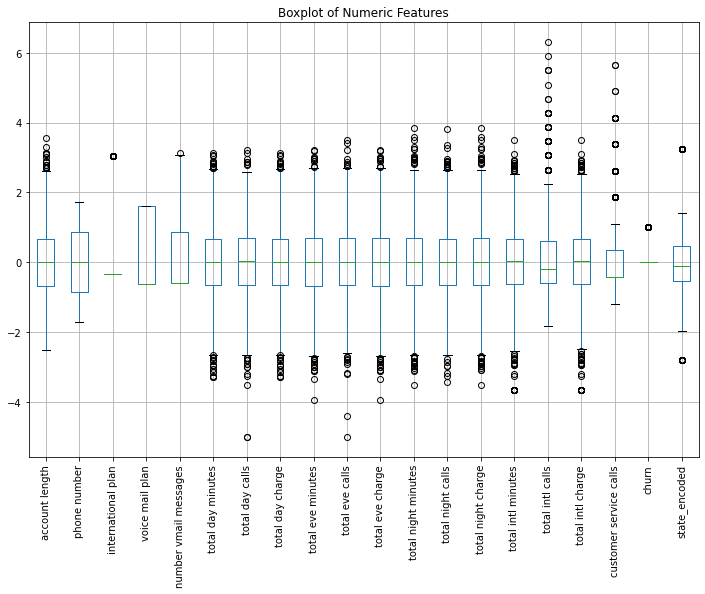

In [136]:
# Boxplots
plt.figure(figsize=(12, 8))
df[numeric_cols].boxplot()
plt.title("Boxplot of Numeric Features")
plt.xticks(rotation=90)
plt.show()

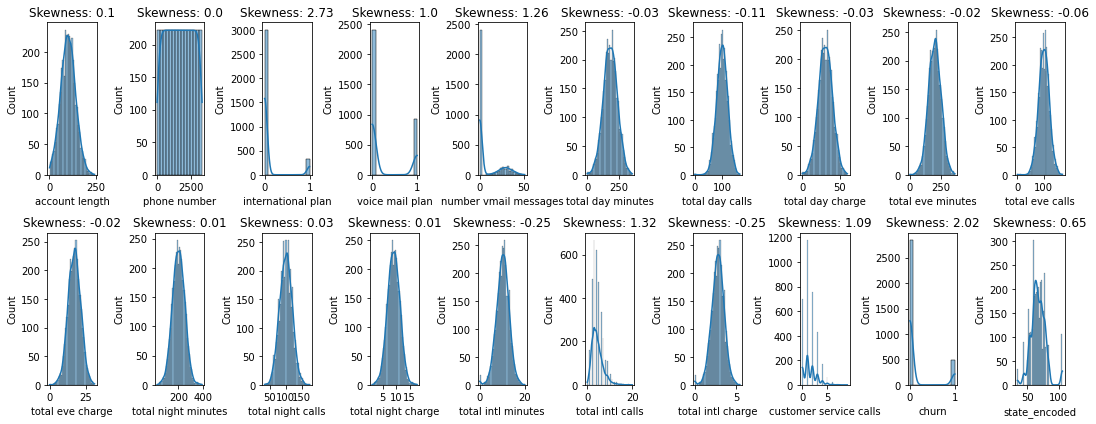

In [119]:
#Plot distributions
fig, axes = plt.subplots(nrows=2, ncols=len(numeric_cols)//2, figsize=(15, 6))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[i])
    axes[i].set_title(f"Skewness: {round(skewness[col], 2)}")
plt.tight_layout()
plt.show()

In [22]:
#Rechecking for outliers
outlier_counts = {}
for col in num_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]
    outlier_counts[col] = outliers.shape[0]

print("Remaining Outlier Counts:", outlier_counts)

Remaining Outlier Counts: {'account length': 0, 'international plan': 0, 'voice mail plan': 0, 'number vmail messages': 0, 'total day minutes': 9, 'total day calls': 0, 'total day charge': 9, 'total eve minutes': 1, 'total eve calls': 3, 'total eve charge': 1, 'total night minutes': 0, 'total night calls': 0, 'total night charge': 0, 'total intl minutes': 0, 'total intl calls': 0, 'total intl charge': 0, 'customer service calls': 0, 'churn': 0}


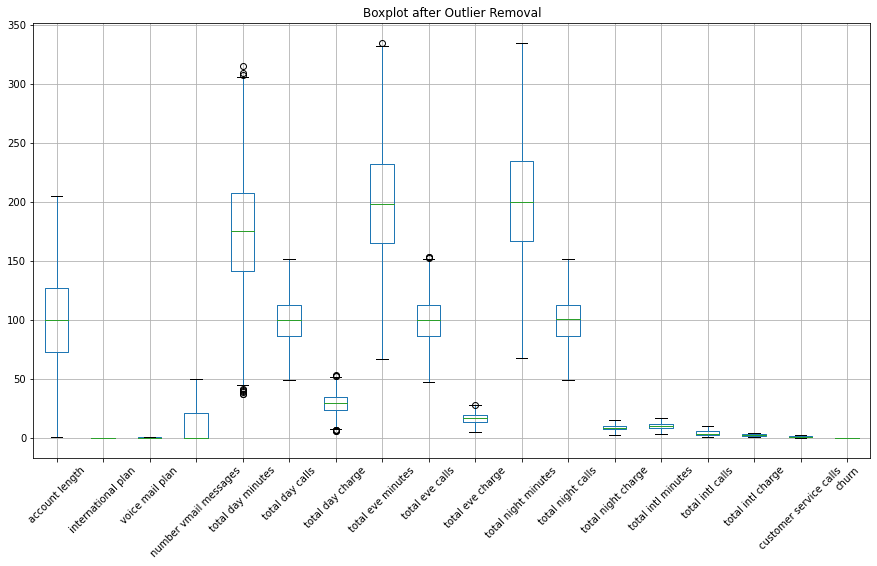

In [23]:
#Boxplots to visualize outliers
plt.figure(figsize=(15, 8))
df_cleaned[num_cols].boxplot(rot=45)
plt.title("Boxplot after Outlier Removal")
plt.show()

In [24]:
df_cleaned.shape

(2328, 19)

In [25]:
df.head()

,state,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
3,OH,84,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,0
4,OK,75,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,0


Feature Engineering

In [122]:
#Feature Scaling

from sklearn.preprocessing import StandardScaler

# Select only numerical columns
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove 'churn' if it exists in the list
if 'churn' in numerical_features:
    numerical_features.remove('churn')

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numerical columns
df[numerical_features] = scaler.fit_transform(df[numerical_features])
# Display the first few rows
df.head()


,account length,phone number,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn,state_encoded
0,0.676489,0.270227,-0.327580,1.617086,1.234883,1.566767,0.476643,1.567036,-0.070610,-0.055940,-0.070427,0.866743,-0.465494,0.866029,-0.085008,-0.601195,-0.085690,-0.427932,0,0.215216
1,0.149065,-0.094579,-0.327580,1.617086,1.307948,-0.333738,1.124503,-0.334013,-0.108080,0.144867,-0.107549,1.058571,0.147825,1.059390,1.240482,-0.601195,1.241169,-0.427932,0,0.888355
2,0.902529,-0.570595,-0.327580,-0.618396,-0.591760,1.168304,0.675985,1.168464,-1.573383,0.496279,-1.573900,-0.756869,0.198935,-0.755571,0.703121,0.211534,0.697156,-1.188218,0,0.046931
3,-0.428590,0.042613,3.052685,-0.618396,-0.591760,2.196596,-1.466936,2.196759,-2.742865,-0.608159,-2.743268,-0.078551,-0.567714,-0.078806,-1.303026,1.024263,-1.306401,0.332354,0,0.888355
4,-0.654629,-1.617204,3.052685,-0.618396,-0.591760,-0.240090,0.626149,-0.240041,-1.038932,1.098699,-1.037939,-0.276311,1.067803,-0.276562,-0.049184,-0.601195,-0.045885,1.092641,0,-0.542066


In [143]:
#Check Mean and Standard Deviation
# Check if the mean is approximately 0 and std dev is 1
df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
account length,3333.0,1.470971e-16,1.00015,-2.513172,-0.679745,-0.001628,0.651374,3.564766
area code,3333.0,4.221046e-16,1.00015,-0.688834,-0.688834,-0.523603,1.718817,1.718817
number vmail messages,3333.0,7.035077e-17,1.00015,-0.591760,-0.591760,-0.591760,0.869554,3.134591
total day minutes,3333.0,7.312216e-16,1.00015,-3.301096,-0.662424,-0.006888,0.672520,3.140422
total day calls,3333.0,-1.934646e-16,1.00015,-5.005247,-0.669570,0.028125,0.675985,3.217588
total day charge,3333.0,-2.835349e-16,1.00015,-3.301162,-0.662376,-0.006730,0.672679,3.140803
total eve minutes,3333.0,-6.821892e-17,1.00015,-3.963622,-0.678030,0.008276,0.676833,3.209066
total eve calls,3333.0,3.288365e-16,1.00015,-5.025911,-0.658361,-0.005739,0.697085,3.508382
total eve charge,3333.0,1.385697e-16,1.00015,-3.963679,-0.678312,0.008459,0.676669,3.207980
total night minutes,3333.0,7.887813e-17,1.00015,-3.513648,-0.669855,0.006486,0.680849,3.839081


In [123]:
df.shape

(3333, 20)

In [126]:
# Feature Engineering
df["total_call_minutes"] = df["total day minutes"] + df["total eve minutes"] + df["total night minutes"]
df["total_charges"] = df["total day charge"] + df["total eve charge"] + df["total night charge"] + df["total intl charge"]
df["call_intensity"] = df["total_call_minutes"] / (df["total day calls"] + df["total eve calls"] + df["total night calls"])

In [127]:
# Binning total call minutes into quartiles
df["call_minutes_category"] = pd.qcut(df["total_call_minutes"], q=4, labels=["Low", "Medium", "High", "Very High"])

# Saving the updated dataset
processed_file_path = "bigml.processed_data.csv"
df.to_csv(processed_file_path, index=False)

In [128]:
df_cleaned.head()

,state,account length,international plan,voice mail plan,number vmail messages,total day minutes,total day calls,total day charge,total eve minutes,total eve calls,total eve charge,total night minutes,total night calls,total night charge,total intl minutes,total intl calls,total intl charge,customer service calls,churn
0,KS,128,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,0
1,OH,107,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,0
2,NJ,137,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,0
11,RI,74,0,0,0,187.7,127,31.91,163.4,148,13.89,196.0,94,8.82,9.1,5,2.46,0,0
12,IA,168,0,0,0,128.8,96,21.90,104.9,71,8.92,141.1,128,6.35,11.2,2,3.02,1,0


In [129]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2328 entries, 0 to 3332
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   state                   2328 non-null   object 
 1   account length          2328 non-null   int64  
 2   international plan      2328 non-null   int64  
 3   voice mail plan         2328 non-null   int64  
 4   number vmail messages   2328 non-null   int64  
 5   total day minutes       2328 non-null   float64
 6   total day calls         2328 non-null   int64  
 7   total day charge        2328 non-null   float64
 8   total eve minutes       2328 non-null   float64
 9   total eve calls         2328 non-null   int64  
 10  total eve charge        2328 non-null   float64
 11  total night minutes     2328 non-null   float64
 12  total night calls       2328 non-null   int64  
 13  total night charge      2328 non-null   float64
 14  total intl minutes      2328 non-null   

In [130]:
df_cleaned.shape

(2328, 19)

Encoding

In [185]:
#Identify Non-Numeric Columns
non_numeric_cols = df.select_dtypes(include=["object"]).columns
print("Non-numeric columns:", non_numeric_cols)

Non-numeric columns: Index(['international plan', 'voice mail plan'], dtype='object')


In [186]:
#Convert 'yes/no' and similar values to binary (if applicable)
for col in non_numeric_cols:
    unique_values = df[col].unique()
    if set(unique_values) == {"yes", "no"}:
        df[col] = df[col].map({"yes": 1, "no": 0})
    else:
        print(f"⚠️ Warning: '{col}' has unexpected values: {unique_values}")

In [187]:
#Check if non-numeric values still exist
if df.select_dtypes(include=["object"]).shape[1] > 0:
    raise ValueError("Some categorical columns were not converted. Please check the dataset.")

In [78]:
# Perform Frequency Encoding on the 'state' column
state_counts = df['state'].value_counts()
df['state_encoded'] = df['state'].map(state_counts)

# Drop the original 'state' column 
df.drop(columns=['state'], inplace=True)

# Save the modified dataset
df.to_csv("bigml.data_encoded.csv", index=False)

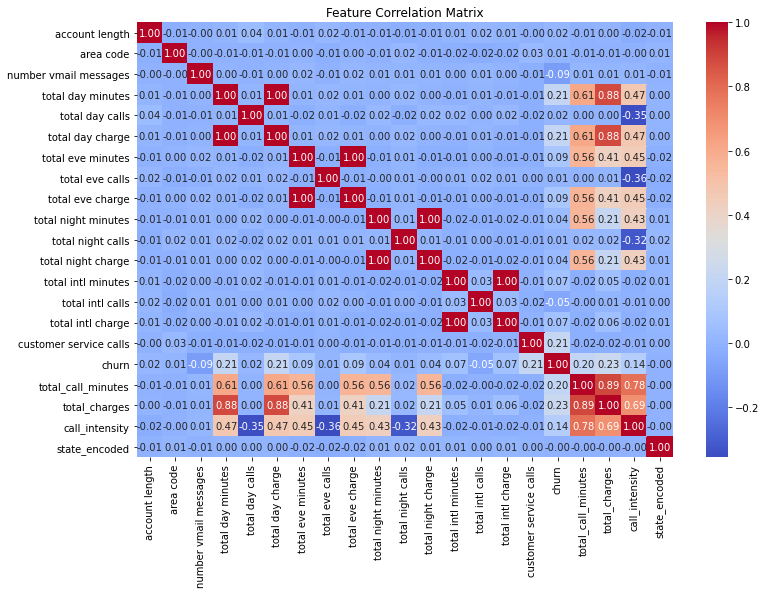

In [180]:
#Correlation Matrix
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Feature Correlation Matrix")
plt.show()

In [79]:
non_numeric_cols = df.select_dtypes(include=["object"]).columns.tolist()

In [69]:
from sklearn.preprocessing import OrdinalEncoder

if non_numeric_cols:
    encoder = OrdinalEncoder()
    df[non_numeric_cols] = encoder.fit_transform(df[non_numeric_cols])

Feature Selection 

In [238]:
print(df.dtypes)

account length              int64
area code                   int64
international plan          int64
voice mail plan             int64
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                        bool
total_call_minutes        float64
total_charges             float64
call_intensity            float64
call_minutes_category       int64
state_encoded               int64
dtype: object


In [87]:
#Convert all columns to numeric
df = df.apply(pd.to_numeric, errors='coerce')
print(df.dtypes)

account length              int64
phone number              float64
international plan          int64
voice mail plan             int64
number vmail messages       int64
total day minutes         float64
total day calls             int64
total day charge          float64
total eve minutes         float64
total eve calls             int64
total eve charge          float64
total night minutes       float64
total night calls           int64
total night charge        float64
total intl minutes        float64
total intl calls            int64
total intl charge         float64
customer service calls      int64
churn                       int32
state_encoded               int64
dtype: object


In [86]:
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0.01)  
df_var = selector.fit_transform(df)
selected_features = df.columns[selector.get_support()]
df = df[selected_features]


Feature Selection

In [88]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel, RFE
from sklearn.preprocessing import LabelEncoder

In [89]:
#Encode categorical target variable if necessary
target_column = 'churn'
if df[target_column].dtype == 'object':
    le = LabelEncoder()
    df[target_column] = le.fit_transform(df[target_column])

In [90]:
# Splitting data into features and target
X = df.drop(columns=[target_column])  
y = df[target_column]  

In [91]:
# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [92]:
# Feature selection using Tree-Based Model (Random Forest)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [93]:
# Select important features
selector = SelectFromModel(rf, threshold='median', prefit=True)
X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)

In [94]:
selected_features = X.columns[selector.get_support()]
rfe_selector = RFE(estimator=rf, n_features_to_select=10, step=1)
rfe_selector.fit(X_train, y_train)
rfe_selected_features = X.columns[rfe_selector.support_]
print("Features selected by Tree-Based Model:", list(selected_features))
print("Features selected by RFE:", list(rfe_selected_features))

Features selected by Tree-Based Model: ['international plan', 'total day minutes', 'total day charge', 'total eve minutes', 'total eve charge', 'total night minutes', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']
Features selected by RFE: ['international plan', 'total day minutes', 'total day charge', 'total eve minutes', 'total eve charge', 'total night charge', 'total intl minutes', 'total intl calls', 'total intl charge', 'customer service calls']


In [96]:
#Transform data using the selected features
X_train_final = X_train[selected_features]
X_test_final = X_test[selected_features]


In [258]:
file_path = "bigml.data.csv"
df = pd.read_csv(file_path)

In [257]:
#Save the refined dataset
X_train_final.to_csv("X_train_selected.csv", index=False)
X_test_final.to_csv("X_test_selected.csv", index=False)


Model Training

In [259]:
# Split into training and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Data split completed.")

Data split completed.


In [260]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [261]:
# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=500)


In [262]:
# Train the model
log_reg.fit(X_train_selected, y_train)

LogisticRegression(max_iter=500)

In [263]:
# Predictions
y_pred_logreg = log_reg.predict(X_test_selected)

In [264]:
# Evaluate
logreg_accuracy = accuracy_score(y_test, y_pred_logreg)
print(f"Logistic Regression Accuracy: {logreg_accuracy:.4f}")
print(classification_report(y_test, y_pred_logreg))

Logistic Regression Accuracy: 0.8576
              precision    recall  f1-score   support

       False       0.87      0.98      0.92       566
        True       0.62      0.16      0.25       101

    accuracy                           0.86       667
   macro avg       0.74      0.57      0.59       667
weighted avg       0.83      0.86      0.82       667



In [265]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train_selected, y_train)

# Predictions
y_pred_rf = rf_model.predict(X_test_selected)

# Evaluate
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9805
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       566
        True       1.00      0.87      0.93       101

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



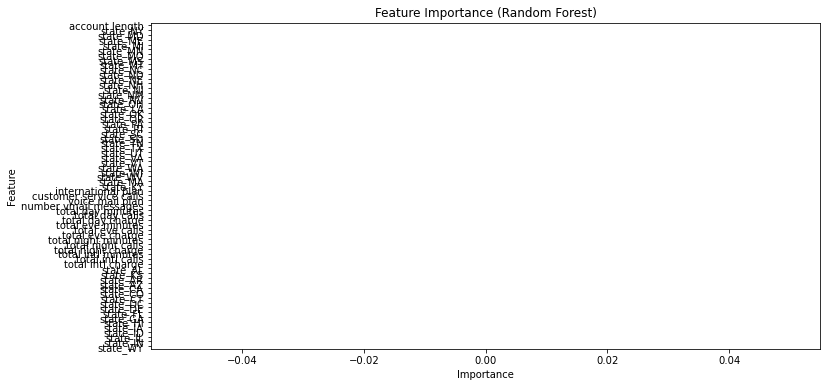

In [112]:
# Get Feature Importance
feature_importances = pd.DataFrame({"Feature": X.columns, "Importance": rf.feature_importances_})
feature_importances = feature_importances.sort_values(by="Importance", ascending=False)
# Plot Feature Importance
plt.figure(figsize=(12, 6))
sns.barplot(x="Importance", y="Feature", data=feature_importances)
plt.title("Feature Importance (Random Forest)")
plt.show()

In [266]:
#XGBoost Training & Evaluation
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

# Initialize XGBoost
xgb_model = XGBClassifier(n_estimators=100, learning_rate=0.1, random_state=42)

# Train the model
xgb_model.fit(X_train_selected, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_selected)

# Evaluate
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(classification_report(y_test, y_pred_xgb))


XGBoost Accuracy: 0.9805
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       566
        True       1.00      0.87      0.93       101

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



In [267]:
#Hyperparameter Tuning for XGBoost
from sklearn.model_selection import GridSearchCV

# Define hyperparameters to tune
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.7, 0.8, 0.9]
}

# Initialize XGBoost model
xgb_model = XGBClassifier(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(xgb_model, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train_selected, y_train)

# Get the best model
best_xgb = grid_search.best_estimator_

# Predict using the best model
y_pred_best_xgb = best_xgb.predict(X_test_selected)

# Evaluate performance
best_xgb_accuracy = accuracy_score(y_test, y_pred_best_xgb)
print(f"Optimized XGBoost Accuracy: {best_xgb_accuracy:.4f}")
print("Best Parameters:", grid_search.best_params_)
print(classification_report(y_test, y_pred_best_xgb))


Optimized XGBoost Accuracy: 0.9805
Best Parameters: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}
              precision    recall  f1-score   support

       False       0.98      1.00      0.99       566
        True       1.00      0.87      0.93       101

    accuracy                           0.98       667
   macro avg       0.99      0.94      0.96       667
weighted avg       0.98      0.98      0.98       667



Model Evaluation

In [273]:
print(globals().keys())  


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'pd', 'np', 'plt', 'sns', 'warnings', '_i2', 'df', '_2', '_i3', '_3', '_i4', '_i5', '_5', '_i6', '_6', '_i7', 'missing_values', '_i8', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', 'duplicate_rows', '_i15', 'stats', 'detect_outliers_zscore', '_i16', 'detect_outliers_iqr', 'num_cols', 'iqr_outliers', '_i17', 'remove_outliers_iqr', 'df_cleaned', '_i18', '_i19', '_i20', 'outlier_counts', 'col', 'Q1', 'Q3', 'IQR', 'lower_bound', 'upper_bound', 'outliers', '_i21', 'StandardScaler', 'numerical_features', '_i22', 'scaler', '_22', '_i23', '_23', '_i24', '_i25', '_i26', '_i27', '_27', '_i28', '_28', '_i29', '_29', '_i30', '_i31', '_31', '_i32', 'num_unique_states', '_i33', '_i34', '_i35', 'df_encoded', '_i36', '_i37', '_i38', '_i39', '_i40', '_i41', '_41', '_i42', '_i43', '_i44', 

In [115]:
import xgboost as xgb

# Define the best parameters (from your tuning process)
best_params = {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.9}

# Train the model again
xgb_best = xgb.XGBClassifier(**best_params, use_label_encoder=False, eval_metric='logloss')
xgb_best.fit(X_train, y_train)


[20:27:24] WARNING: C:\Users\Administrator\workspace\xgboost-win64_release_1.2.0\src\learner.cc:516: 
Parameters: { use_label_encoder } might not be used.

  This may not be accurate due to some parameters are only used in language bindings but
  passed down to XGBoost core.  Or some parameters are not used but slip through this
  verification. Please open an issue if you find above cases.




XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, eval_metric='logloss',
              gamma=0, gpu_id=-1, importance_type='gain',
              interaction_constraints='', learning_rate=0.01, max_delta_step=0,
              max_depth=3, min_child_weight=1, missing=nan,
              monotone_constraints='()', n_estimators=300, n_jobs=0,
              num_parallel_tree=1, random_state=0, reg_alpha=0, reg_lambda=1,
              scale_pos_weight=1, subsample=0.9, tree_method='exact',
              use_label_encoder=False, validate_parameters=1, verbosity=None)

In [116]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Make predictions
y_pred = xgb_best.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"XGBoost Model Accuracy: {accuracy:.4f}")

# Display classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Display confusion matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))


XGBoost Model Accuracy: 0.9430

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.99      0.97       566
           1       0.91      0.69      0.79       101

    accuracy                           0.94       667
   macro avg       0.93      0.84      0.88       667
weighted avg       0.94      0.94      0.94       667


Confusion Matrix:
[[559   7]
 [ 31  70]]


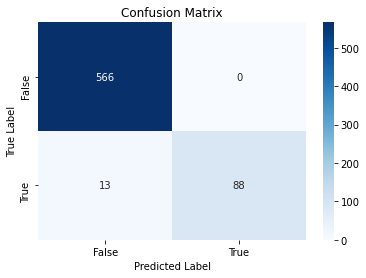

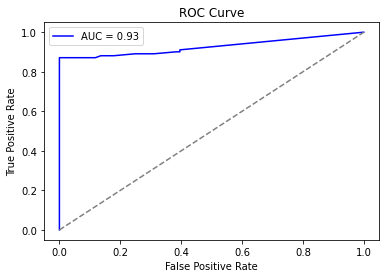

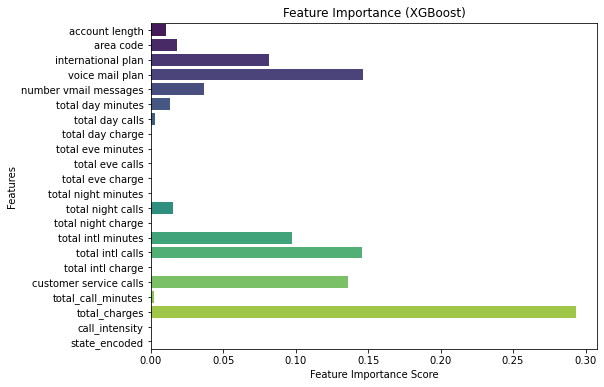

In [278]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Confusion Matrix Heatmap
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# 2. ROC Curve & AUC Score
y_prob = xgb_best.predict_proba(X_test)[:, 1] 
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc:.2f}')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--')  
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# 3. Feature Importance Plot
plt.figure(figsize=(8, 6))
importance = xgb_best.feature_importances_
sns.barplot(x=importance, y=X_train.columns, palette="viridis")
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Feature Importance (XGBoost)")
plt.show()


# Conclusion and Recommendation
- Random Forest Classifier performed well and is a reliable choice due to its robustness and ability to handle complex relationships in the data.
- Logistic Regression is an efficient and interpretable model, particularly useful for scenarios requiring probability estimation and interpretability.
- Decision Tree Classifier achieved an accuracy of 95.35%, indicating strong performance but slightly lower generalizability than ensemble models like Random Forest and XGBoost.
- Logistic Regression or Decision Tree may be preferable, as they provide clearer insights into feature importance.